1) Consistency Check

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Load and Clean
df = pd.read_csv('Textile_data2.txt.csv')
df.columns = df.columns.str.strip()
df = df.dropna()

# Rename to match Business Logic
df = df.rename(columns={
    'Item': 'Product_Category',
    'Cost Price': 'Buying_Cost',
    'Sale Price': 'Selling_Price'
})

df.head() # Show the first 5 rows to verify

,Item Number,Timestamp,Product_Category,Material,Supplier,Location,Season,Buying_Cost,Selling_Price,MRP,Quality,Availability
0,1,10/22/2024 15:20:18,Cotton saree,Cotton,Emco textiles,Jetpur,Summer,300,330,400,Good,Yes
1,2,10/22/2024 15:22:35,Blouse piece,Cotton,Shree fabrics,Pali,All time,40,50,70,Good,Yes
2,3,10/22/2024 15:24:56,Lungi,Cotton,Shree Ram textiles,Erode,All time,100,120,150,Good,Yes
3,4,10/22/2024 15:26:32,Saree,Silk,Sri Lakshmi silks,Surat,Marriage,600,700,900,Good,Yes
4,5,10/22/2024 15:28:47,Churidhar,Cotton,Vasanth textiles,Tirupur,All time,250,300,400,Good,Yes


2. Feature Selection & Model Training

In [14]:
# Define X and y
X = df[['Buying_Cost']]
y = df['Selling_Price']

# Build Random Forest Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

print("✅ Model training complete!")

✅ Model training complete!


3.Predictions & Decision Rules

In [16]:
# 1. Predict for a new item costing 1200
# We name it 'test_data' and use that same name in the next line
test_data = pd.DataFrame([[1200]], columns=['Buying_Cost'])
predicted = model.predict(test_data)

print(f"🔮 Predicted Selling Price: {predicted[0]:.2f}")

# 2. Safety Stock / Inventory Alert logic
# This checks your 'Availability' column for 'No'
df['Low_Stock'] = df['Availability'] == 'No'
low_stock = df[df['Low_Stock']]

print(f"🚨 INVENTORY ALERT: {len(low_stock)} items out of stock.")

🔮 Predicted Selling Price: 1300.00
🚨 INVENTORY ALERT: 0 items out of stock.


4.Visualizing Findings

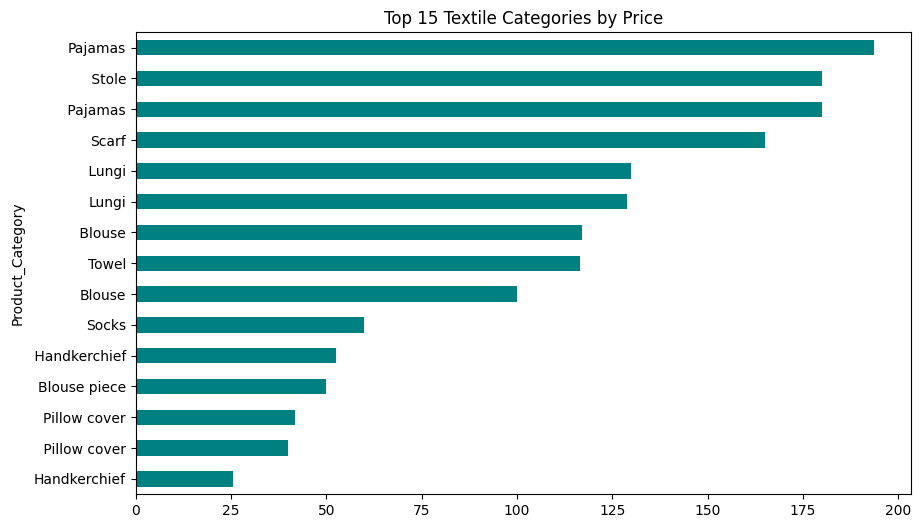


✅ Model Accuracy: 0.9985


In [18]:
plt.figure(figsize=(10, 6))
df.groupby('Product_Category')['Selling_Price'].mean().sort_values().head(15).plot(kind='barh', color='teal')
plt.title('Top 15 Textile Categories by Price')
plt.show()

# Accuracy Check
print(f"\n✅ Model Accuracy: {r2_score(y, model.predict(X)):.4f}")